# SLM mask centre alignment

This notebook locates the incident beam on the SLM in three stages:

1. A coarse full-screen stripe-curtain sweep.
2. A fine golden-section centre search.
3. An optional beam-radius scan and plateau measurement.

Start the camera and SLM servers before running the notebook. The camera viewer is also needed to estimate the beam centre and measurement-window dimensions.


## Server session

On the Linux control machine, attach to the server session with:

```bash
tmux attach -t pwi_servers
```

In [17]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import JazLabs.hardware.SLM.PhaseMaskClass as PhaseMaskClass
from JazLabs.hardware.SLM.SLMStack import SLMClient
import JazLabs.procedures.SLM.SLM_CenterAlignment as SLM_CenterAlignment

import JazLabs.hardware.Cameras.Camera_Client as CamClientlib


In [2]:
%load_ext autoreload
%aimport JazLabs.procedures.SLM.SLM_CenterAlignment 
%autoreload 1


## Configuration

Use the camera viewer to estimate the beam centre and the width of the measurement window. Update the connection ports and alignment parameters here before connecting to the hardware.

In [18]:
XbeamCenterOnCam = 64
YbeamCenterOnCam = 64
XbeamWindwowWidth = 30
YbeamWindwowWidth = 30

stripe_width = 15
MaskSize = [600, 600]
stepCount = 100
BeamRadiusScanFinalRadius = 150

CAM_COM_PORT = 50733
CAM_FRAME_PORT = 50734
SLM_COM_PORT = 5555
SLM_DISP_PORT = 5556

## Connect to the hardware

Create camera and SLM clients using the configured server ports. Existing notebook clients are closed first so rerunning these cells does not leave duplicate connections.

In [19]:
try:
    cam_slm.close()
except NameError:
    pass

cam_slm = CamClientlib.CameraClient(
    host="127.0.0.1",
    command_port=CAM_COM_PORT,
    frame_pub_port=CAM_FRAME_PORT,
    timeout_ms=60000,
    client_id="camera_notebook",
)

In [20]:
try:
    slmobj_client.close()
except NameError:
    pass
slmobj_client = SLMClient(
    host='127.0.0.1',
    command_port=SLM_COM_PORT,
    display_pub_port=SLM_DISP_PORT,
    timeout_ms=5000,
    attach_viewer_shared_memory=False,
)
phasemaskobj = PhaseMaskClass.PhaseMaskObject(
    SLMObject=slmobj_client,
    ActiveRGBChannels=["Red"],
    pixel_size=17e-6,
    wavelength=1550e-9,
)
slmobj_client.LoadLutFile("C:\\Program Files\\Meadowlark Optics\\Blink OverDrive Plus\\LUT Files\\SLM6658_at1550_75c_2.lut")
slmobj_client.SetRefreshRate(40e-3)




        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


0.04

## Create the alignment controller

The alignment controller coordinates each SLM update with a triggered camera measurement.

In [23]:
SLM_CenterAlignmentObj = SLM_CenterAlignment.AlginmentObj(
    slmObjs=[phasemaskobj],
    CamObjs=[cam_slm],
)

1


## Coarse beam-centre sweep

Reveal the full-screen binary stripe pattern from one edge of the SLM. The minimum metric in each direction provides the starting centre for the fine search.

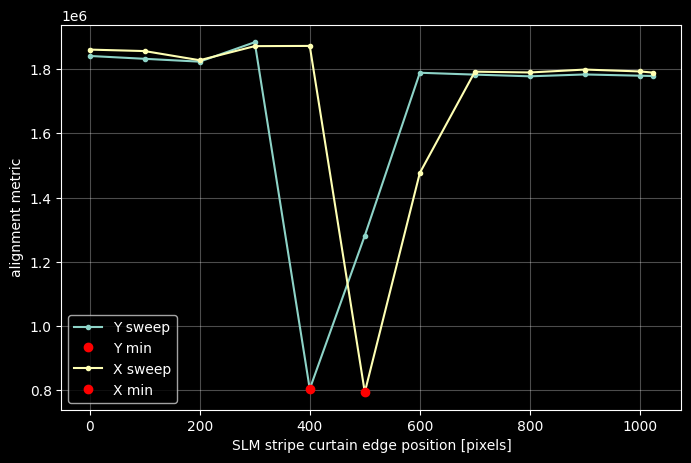

SLM course center found at: X=500.0, Y=400.0


In [7]:
StripRefSigPWR, StripRefSigPWR_log, StripSweepStep = SLM_CenterAlignmentObj.SweepAcrossSLM_StripProfile(
    ObjIdx=0,
    channel="Red",
    stepCount=stepCount,
    StartingSweepPoint=0,
    strip_width=stripe_width,
    avgFrameCount=1,
    ixCamCenter=YbeamCenterOnCam,
    iyCamCenter=XbeamCenterOnCam,
    x_half_width=XbeamWindwowWidth // 2,
    y_half_width=YbeamWindwowWidth // 2,
    MetricType="POWERMinusHalfRef",
)
yminidx_slmCourseCenter=np.argmin(StripRefSigPWR[0, :, 0]) #ysweep
xminidx_slmCourseCenter=np.argmin(StripRefSigPWR[1, :, 0]) #xsweep
ymin_slmCourseCenter=StripSweepStep[0, yminidx_slmCourseCenter, 0]
xmin_slmCourseCenter=StripSweepStep[1, xminidx_slmCourseCenter, 0]

plt.figure(figsize=(8, 5))
plt.plot(StripSweepStep[0, :, 0], StripRefSigPWR[0, :, 0], ".-", label="Y sweep")
plt.plot(ymin_slmCourseCenter, StripRefSigPWR[0, yminidx_slmCourseCenter, 0], "ro", label="Y min")
plt.plot(StripSweepStep[1, :, 0], StripRefSigPWR[1, :, 0], ".-", label="X sweep")
plt.plot(xmin_slmCourseCenter, StripRefSigPWR[1, xminidx_slmCourseCenter, 0], "ro", label="X min")
plt.xlabel("SLM stripe curtain edge position [pixels]")
plt.ylabel("alignment metric")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# set the centers to the found values
# trun the Vpol mask off
phasemaskobj.polProps["Red"]['V'].polEnabled=False
# move Hpol mask to center
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[1] = xmin_slmCourseCenter
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[0] = ymin_slmCourseCenter
# phasemaskobj.setmask(channel="Red",imode=1)

print(f"SLM course center found at: X={xmin_slmCourseCenter}, Y={ymin_slmCourseCenter}")



## Fine centre alignment

Run two phase-flip golden searches in X and Y around the coarse centre. The tracking plots show the measured samples, the minimum from each flip, the original centre, and the selected average centre.

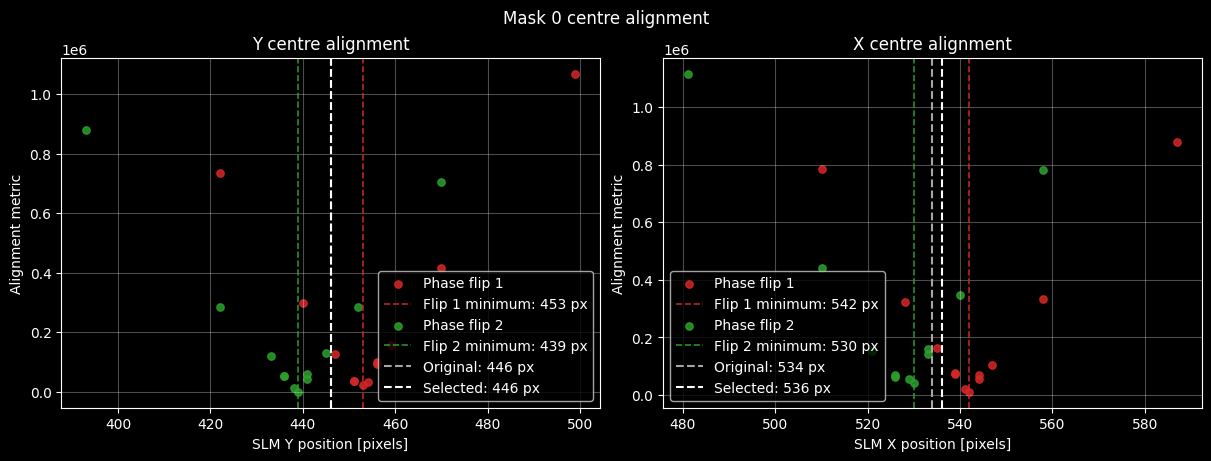

In [11]:

MinXCenter, MinYCenter = SLM_CenterAlignmentObj.PerformCenterAlignment_GoldenSearch(
    ObjIdx=0,
    channel="Red",
    pol="H",
    ApplyZernike=False,
    MaskSize=MaskSize,
    PixelsCountFromCenters=stepCount,
    PlotTracking=True,
    Verbose=False,
    BackgroundPhase=0,
    avgFrameCount=1,
    MetricType="POWERMinusHalfRef",
    stripe_width=stripe_width,
    ixCamCenter=YbeamCenterOnCam,
    iyCamCenter=XbeamCenterOnCam,
    x_half_width=XbeamWindwowWidth // 2,
    y_half_width=YbeamWindwowWidth // 2,
)

## Save the aligned mask centres

Persist the updated mask properties after checking the fine-alignment plots.

In [12]:
phasemaskobj.saveMaskProperties(filenamePrefix="SLM_CenterAlignment.npy")

## Optional: reload saved centres

Run this cell only when you want to restore and verify the saved mask properties. It is not required immediately after saving.

In [21]:
phasemaskobj.LoadMaskProperties(filenamePrefix="SLM_CenterAlignment.npy")

## Beam-radius and plateau check

Increase the circular SLM aperture and measure when the detected power reaches its final plateau. The first measured-data intersection with the estimated plateau gives a practical beam-radius estimate.

POWER
Final plateau level: 2.59067e+06
First intersection: 113.06 pixels


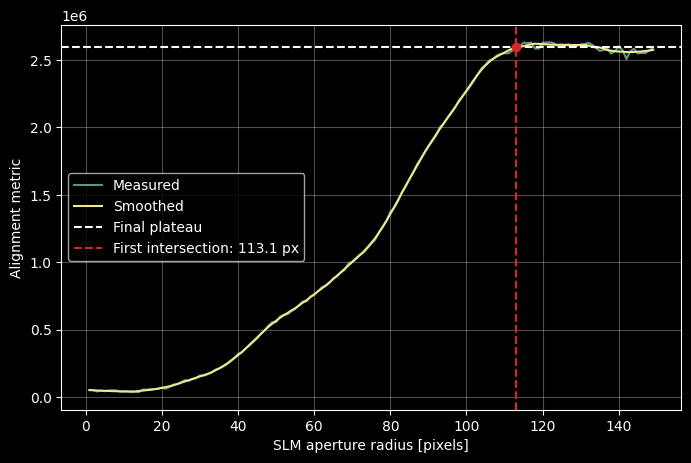

In [29]:
beam_radius, beam_metric = SLM_CenterAlignmentObj.Beam_size_scan_on_SLM(
    ObjIdx=0,
    channel="Red",
    pol="H",
    ApplyZernike=False,
    InitalRadius=1,
    FinalRadius=BeamRadiusScanFinalRadius,
    radiusStep=1,
    avgFrameCount=1,
    PlotResults=False,
    MetricType="POWER",
    ixCamCenter=YbeamCenterOnCam,
    iyCamCenter=XbeamCenterOnCam,
    x_half_width=YbeamWindwowWidth // 2,
    y_half_width=XbeamWindwowWidth // 2,
)
plateau_start, plateau_level = SLM_CenterAlignment.FindPlateauStart(
    beam_radius,
    beam_metric,
    smoothing_window=15,
    plateau_tail_fraction=0.20,
    PlotResults=True,
)

